In [2]:
import requests
import io
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import MaxNLocator
import xarray as xr
import geopandas as gpd
import pandas as pd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import os
import glob
import seaborn as sns
from IPython.display import HTML
import regionmask

Suggested Figures to complete the story:
-

Bar charts statewide seasonality (monthly counts)Hours and precip sum
- Recent climate normal statewide and Regional of focus 
- ERA5 31km and 4km (comparing)


Decadal counts storm hours --Hours and precip sum
- 4km decadal periods 1960-2010’s 
- regional and statewide 

Numbers of extremes by decade? 
- Above 5th percentile ?


Case study of exploring comparison between ASOS and ERA5 4km 
- Snotel Site Comparison
	2021 and 2011 


Loading in the Data 
-

In [3]:
shapefile_path = "/center1/DYNDOWN/phutton5/ROS/boundaries/Alaska_Borough_and_Census_Area_Boundaries.shp"
borough_boundaries = gpd.read_file(shapefile_path)
borough_boundaries = borough_boundaries.set_crs(epsg=3338)
borough_boundaries = borough_boundaries.to_crs(epsg=4326)

Mun_of_Anc_boundary = borough_boundaries[borough_boundaries['CommunityN'] == 'Municipality of Anchorage']
Bethel_boundary = borough_boundaries[borough_boundaries['CommunityN'] == 'Bethel Census Area']
Mat_Su_boundary=borough_boundaries[borough_boundaries['CommunityN'] == 'Matanuska-Susitna Borough']
Denali_boundary=borough_boundaries[borough_boundaries['CommunityN'] == 'Denali Borough']

FNSB_boundary = borough_boundaries[borough_boundaries['CommunityN'] == 'Fairbanks North Star Borough']
FNSB_geom = FNSB_boundary.geometry.iloc[0] 
FNSB_coords = []
FNSB_coords.extend(list(FNSB_geom.exterior.coords))
FNSB_coords = np.array(FNSB_coords)  
FNSB_coords = pd.DataFrame({
    "lon": FNSB_coords[:, 0],
    "lat": FNSB_coords[:, 1]})

Fairbanks_lat=(64.84)
Fairbanks_lon=(-147.72)

In [4]:
'''path='/center1/DYNDOWN/phutton5/ROS/All_of_AK/All_of_AK_netcdf_files/'
compare=f'ROS_Monthly_*.nc'
file_list = sorted(glob.glob(os.path.join(path, compare)))
combined_ds=xr.open_mfdataset(file_list, combine='by_coords',engine='netcdf4')

os.chdir("/import/beegfs/CMIP6/wrf_era5")
geo_em_path = "geo_em.d02.nc"
geo = xr.open_dataset(geo_em_path)
oceanmask=geo['LU_INDEX']
oceanmask=oceanmask.squeeze(dim='Time')
#oceanmask_expanded = oceanmask.expand_dims(Time=data.Time)

combined_ds = combined_ds.where(oceanmask != 17)
era5_4km=combined_ds

era54kmlat = combined_ds['XLAT'].values
era54kmlon = combined_ds['XLONG'].values

ROS_Tally_era5_4km=np.sum(era5_4km['ros_tally'],axis=1)
ROS_Tally_seasonal_era5_4km=np.mean(ROS_Tally_era5_4km,axis=0)

ROS_Rain_sum_era5_4km=np.sum(era5_4km['rain_ros_sum'],axis=1)
ROS_Rain_seasonal_sum_era5_4km=np.mean(ROS_Rain_sum_era5_4km,axis=0)

lat = combined_ds['XLAT'].values
lon = combined_ds['XLONG'].values'''

'path=\'/center1/DYNDOWN/phutton5/ROS/All_of_AK/All_of_AK_netcdf_files/\'\ncompare=f\'ROS_Monthly_*.nc\'\nfile_list = sorted(glob.glob(os.path.join(path, compare)))\ncombined_ds=xr.open_mfdataset(file_list, combine=\'by_coords\',engine=\'netcdf4\')\n\nos.chdir("/import/beegfs/CMIP6/wrf_era5")\ngeo_em_path = "geo_em.d02.nc"\ngeo = xr.open_dataset(geo_em_path)\noceanmask=geo[\'LU_INDEX\']\noceanmask=oceanmask.squeeze(dim=\'Time\')\n#oceanmask_expanded = oceanmask.expand_dims(Time=data.Time)\n\ncombined_ds = combined_ds.where(oceanmask != 17)\nera5_4km=combined_ds\n\nera54kmlat = combined_ds[\'XLAT\'].values\nera54kmlon = combined_ds[\'XLONG\'].values\n\nROS_Tally_era5_4km=np.sum(era5_4km[\'ros_tally\'],axis=1)\nROS_Tally_seasonal_era5_4km=np.mean(ROS_Tally_era5_4km,axis=0)\n\nROS_Rain_sum_era5_4km=np.sum(era5_4km[\'rain_ros_sum\'],axis=1)\nROS_Rain_seasonal_sum_era5_4km=np.mean(ROS_Rain_sum_era5_4km,axis=0)\n\nlat = combined_ds[\'XLAT\'].values\nlon = combined_ds[\'XLONG\'].values'

In [ ]:
#Regridded ERA5 31km
regridded_era5_path='/center1/DYNDOWN/phutton5/ROS/All_of_AK/All_of_AK_netcdf_files/ERA5_31kmto4km_nearest_regridded.nc'
regridded_era5=xr.open_dataset(regridded_era5_path)

#ERA5  4km
era5_4km='/center1/DYNDOWN/phutton5/ROS/All_of_AK/All_of_AK_netcdf_files/ROS_Monthly_*.nc'
era5_4km = xr.open_mfdataset(era5_4km,combine="by_coords", parallel=True)

In [113]:
os.chdir("/import/beegfs/CMIP6/wrf_era5")
geo_em_path = "geo_em.d02.nc"
geo = xr.open_dataset(geo_em_path)
oceanmask=geo['LU_INDEX']
oceanmask=oceanmask.squeeze(dim='Time')

era5_4km = era5_4km.where(oceanmask != 17)
regridded_era5 = regridded_era5.where(oceanmask != 17)

elevation=geo['HGT_M']
elevation


<xarray.DataArray 'HGT_M' (Time: 1, south_north: 450, west_east: 420)> Size: 756kB
[189000 values with dtype=float32]
Dimensions without coordinates: Time, south_north, west_east
Attributes:
    FieldType:    104
    MemoryOrder:  XY 
    units:        meters MSL
    description:  GMTED2010 30-arc-second topography height
    stagger:      M
    sr_x:         1
    sr_y:         1

In [114]:
seasons=era5_4km['season']
lat=era5_4km['XLAT']
lon=era5_4km['XLONG']

At single point #not initally used but brougbt over incase I need it !

In [8]:
def getXY(lat, lon, dataarray):
    abslat = np.abs(dataarray.XLAT-lat)
    abslon = np.abs(dataarray.XLONG-lon)
    d = abslon**2 + abslat**2
    flat_index = np.argmin(d.values)
    yloc, xloc = np.unravel_index(flat_index, d.shape)
    return xloc, yloc

In [9]:
monthlist=['November','December','January','February','March' ]
monthnumberlist=[11,12,1,2,3]

#era5 4km
ros_total_4km=era5_4km['ros_tally'].sum(axis=1).mean(axis=0)
ros_rain_sum_season_total_SUM_4km=era5_4km['rain_ros_sum'].sum(axis=1).mean(axis=0)

nov_ros_tally_avg_4km=np.mean(era5_4km['ros_tally'].sel(month=11),axis=0)
dec_ros_tally_avg_4km=np.mean(era5_4km['ros_tally'].sel(month=12),axis=0)
jan_ros_tally_avg_4km=np.mean(era5_4km['ros_tally'].sel(month=1),axis=0)
feb_ros_tally_avg_4km=np.mean(era5_4km['ros_tally'].sel(month=2),axis=0)
mar_ros_tally_avg_4km=np.mean(era5_4km['ros_tally'].sel(month=3),axis=0)

nov_ros_rain_sum_avg_4km=np.mean(era5_4km['rain_ros_sum'].sel(month=11),axis=0)
dec_ros_rain_sum_avg_4km=np.mean(era5_4km['rain_ros_sum'].sel(month=12),axis=0)
jan_ros_rain_sum_avg_4km=np.mean(era5_4km['rain_ros_sum'].sel(month=1),axis=0)
feb_ros_rain_sum_avg_4km=np.mean(era5_4km['rain_ros_sum'].sel(month=2),axis=0)
mar_ros_rain_sum_avg_4km=np.mean(era5_4km['rain_ros_sum'].sel(month=3),axis=0)

#era5 31km
'''
ros_total_31km=regridded_era5['ros_tally'].sum(axis=1).mean(axis=0)
ros_rain_sum_season_total_SUM_31km=regridded_era5['rain_ros_sum'].sum(axis=1).mean(axis=0)

nov_ros_tally_avg_31km=np.mean(regridded_era5['ros_tally'].sel(month=11),axis=0)
dec_ros_tally_avg_31km=np.mean(regridded_era5['ros_tally'].sel(month=12),axis=0)
jan_ros_tally_avg_31km=np.mean(regridded_era5['ros_tally'].sel(month=1),axis=0)
feb_ros_tally_avg_31km=np.mean(regridded_era5['ros_tally'].sel(month=2),axis=0)
mar_ros_tally_avg_31km=np.mean(regridded_era5['ros_tally'].sel(month=3),axis=0)

nov_ros_rain_sum_avg_31km=np.mean(regridded_era5['rain_ros_sum'].sel(month=11),axis=0)
dec_ros_rain_sum_avg_31km=np.mean(regridded_era5['rain_ros_sum'].sel(month=12),axis=0)
jan_ros_rain_sum_avg_31km=np.mean(regridded_era5['rain_ros_sum'].sel(month=1),axis=0)
feb_ros_rain_sum_avg_31km=np.mean(regridded_era5['rain_ros_sum'].sel(month=2),axis=0)
mar_ros_rain_sum_avg_31km=np.mean(regridded_era5['rain_ros_sum'].sel(month=3),axis=0)
'''

"\nros_total_31km=regridded_era5['ros_tally'].sum(axis=1).mean(axis=0)\nros_rain_sum_season_total_SUM_31km=regridded_era5['rain_ros_sum'].sum(axis=1).mean(axis=0)\n\nnov_ros_tally_avg_31km=np.mean(regridded_era5['ros_tally'].sel(month=11),axis=0)\ndec_ros_tally_avg_31km=np.mean(regridded_era5['ros_tally'].sel(month=12),axis=0)\njan_ros_tally_avg_31km=np.mean(regridded_era5['ros_tally'].sel(month=1),axis=0)\nfeb_ros_tally_avg_31km=np.mean(regridded_era5['ros_tally'].sel(month=2),axis=0)\nmar_ros_tally_avg_31km=np.mean(regridded_era5['ros_tally'].sel(month=3),axis=0)\n\nnov_ros_rain_sum_avg_31km=np.mean(regridded_era5['rain_ros_sum'].sel(month=11),axis=0)\ndec_ros_rain_sum_avg_31km=np.mean(regridded_era5['rain_ros_sum'].sel(month=12),axis=0)\njan_ros_rain_sum_avg_31km=np.mean(regridded_era5['rain_ros_sum'].sel(month=1),axis=0)\nfeb_ros_rain_sum_avg_31km=np.mean(regridded_era5['rain_ros_sum'].sel(month=2),axis=0)\nmar_ros_rain_sum_avg_31km=np.mean(regridded_era5['rain_ros_sum'].sel(month=

Breaking into two climate normals
- 

In [10]:
era5_4km_1950_1979 = era5_4km.sel(season=slice('1951-1952', '1980-1981'))
era5_4km_1991_2020 = era5_4km.sel(season=slice('1991-1992', '2020-2021'))
#regridded_era5_1950_1979 = regridded_era5.sel(season=slice('1951-1952', '1980-1981'))
#regridded_era5_1991_2020 = regridded_era5.sel(season=slice('1991-1992', '2020-2021'))

# 1950-1979
era5_4km_nov_ros_1950_1979 = era5_4km_1950_1979['rain_ros_sum'].sel(month=11).mean(dim='season')
era5_4km_dec_ros_1950_1979 = era5_4km_1950_1979['rain_ros_sum'].sel(month=12).mean(dim='season')
era5_4km_jan_ros_1950_1979 = era5_4km_1950_1979['rain_ros_sum'].sel(month=1).mean(dim='season')
era5_4km_feb_ros_1950_1979 = era5_4km_1950_1979['rain_ros_sum'].sel(month=2).mean(dim='season')
era5_4km_mar_ros_1950_1979 = era5_4km_1950_1979['rain_ros_sum'].sel(month=3).mean(dim='season')

#regridded_era5_nov_ros_1950_1979 = regridded_era5_1950_1979['ros_tally'].sel(month=11).mean(dim='season')
#regridded_era5_dec_ros_1950_1979 = regridded_era5_1950_1979['ros_tally'].sel(month=12).mean(dim='season')
#regridded_era5_jan_ros_1950_1979 = regridded_era5_1950_1979['ros_tally'].sel(month=1).mean(dim='season')
#regridded_era5_feb_ros_1950_1979 = regridded_era5_1950_1979['ros_tally'].sel(month=2).mean(dim='season')
#regridded_era5_mar_ros_1950_1979 = regridded_era5_1950_1979['ros_tally'].sel(month=3).mean(dim='season')

# 1991-2020
era5_4km_nov_ros_1991_2020 = era5_4km_1991_2020['rain_ros_sum'].sel(month=11).mean(dim='season')
era5_4km_dec_ros_1991_2020 = era5_4km_1991_2020['rain_ros_sum'].sel(month=12).mean(dim='season')
era5_4km_jan_ros_1991_2020 = era5_4km_1991_2020['rain_ros_sum'].sel(month=1).mean(dim='season')
era5_4km_feb_ros_1991_2020 = era5_4km_1991_2020['rain_ros_sum'].sel(month=2).mean(dim='season')
era5_4km_mar_ros_1991_2020 = era5_4km_1991_2020['rain_ros_sum'].sel(month=3).mean(dim='season')

#regridded_era5_nov_ros_1991_2020 = regridded_era5_1991_2020['ros_tally'].sel(month=11).mean(dim='season')
#regridded_era5_dec_ros_1991_2020 = regridded_era5_1991_2020['ros_tally'].sel(month=12).mean(dim='season')
##regridded_era5_jan_ros_1991_2020 = regridded_era5_1991_2020['ros_tally'].sel(month=1).mean(dim='season')
#regridded_era5_feb_ros_1991_2020 = regridded_era5_1991_2020['ros_tally'].sel(month=2).mean(dim='season')
#regridded_era5_mar_ros_1991_2020 = regridded_era5_1991_2020['ros_tally'].sel(month=3).mean(dim='season')


In [11]:
era5_4km_1950_1979_monthly_rain_ros_sum = {
    'nov': era5_4km_1950_1979['rain_ros_sum'].sel(month=11).mean(dim='season'),
    'dec': era5_4km_1950_1979['rain_ros_sum'].sel(month=12).mean(dim='season'),
    'jan': era5_4km_1950_1979['rain_ros_sum'].sel(month=1).mean(dim='season'),
    'feb': era5_4km_1950_1979['rain_ros_sum'].sel(month=2).mean(dim='season'),
    'mar': era5_4km_1950_1979['rain_ros_sum'].sel(month=3).mean(dim='season')}

era5_4km_1991_2020_monthly_rain_ros_sum={
    'nov': era5_4km_1991_2020['rain_ros_sum'].sel(month=11).mean(dim='season'),
    'dec': era5_4km_1991_2020['rain_ros_sum'].sel(month=12).mean(dim='season'),
    'jan': era5_4km_1991_2020['rain_ros_sum'].sel(month=1).mean(dim='season'),
    'feb': era5_4km_1991_2020['rain_ros_sum'].sel(month=2).mean(dim='season'),
    'mar': era5_4km_1991_2020['rain_ros_sum'].sel(month=3).mean(dim='season') }

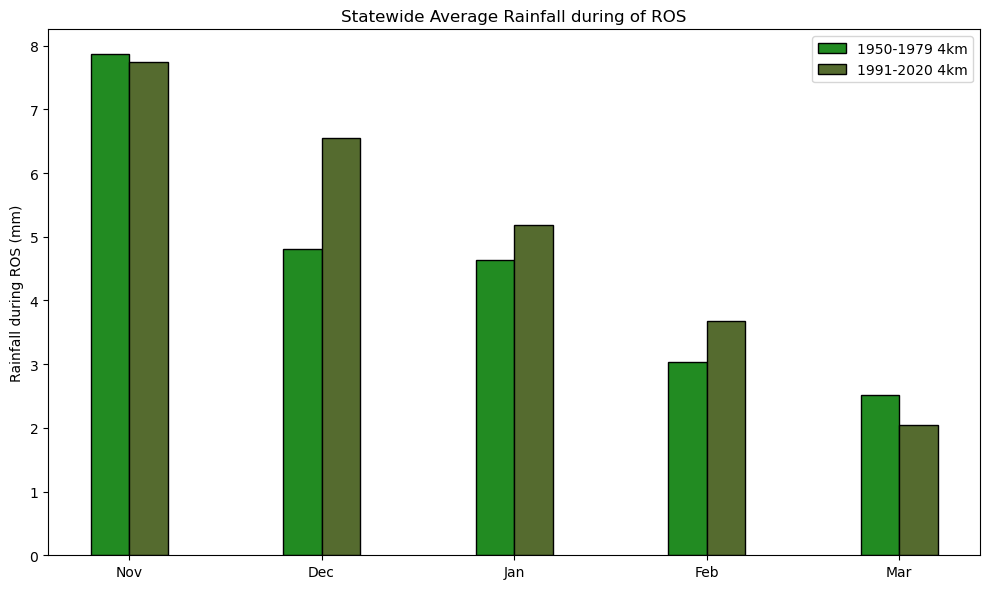

In [12]:
def monthly_avg(data_dict):
    return [np.nanmean(data_dict[month].values) for month in ['nov','dec','jan','feb','mar']]

avg_1950_4km = monthly_avg(era5_4km_1950_1979_monthly_rain_ros_sum)
avg_1991_4km = monthly_avg(era5_4km_1991_2020_monthly_rain_ros_sum)

month_labels = ['Nov', 'Dec', 'Jan', 'Feb', 'Mar']
x = np.arange(len(month_labels))
width = 0.2
fig, ax = plt.subplots(figsize=(10,6))

ax.bar(x - .5*width, avg_1950_4km, width, color='forestgreen', edgecolor='black', label='1950-1979 4km')
ax.bar(x +0.5*width, avg_1991_4km, width, color='darkolivegreen', edgecolor='black', label='1991-2020 4km')
ax.set_xticks(x)
ax.set_xticklabels(month_labels)
ax.set_ylabel('Rainfall during ROS (mm)')
ax.set_title('Statewide Average Rainfall during of ROS')
ax.legend()
plt.tight_layout()
plt.show()

Regional Analysis 
-

In [13]:
def borough_land_mask(shapefile,data,lat,lon):
    mask = regionmask.mask_geopandas(shapefile, lon, lat)
    data_masked = data.where(~np.isnan(mask))
    return data_masked

In [14]:
def apply_borough_mask(datasets, shapefile):
    masked_datasets = {}
    for month, data in datasets.items():
        masked = borough_land_mask(shapefile, data, data.XLAT, data.XLONG)
        masked_datasets[month] = masked
    return masked_datasets

In [15]:
def monthly_avg(data_dict):
    return [np.nanmean(data_dict[month].values) for month in ['nov','dec','jan','feb','mar']]

In [16]:
anc_era5_4km_1950_1979 = apply_borough_mask(era5_4km_1950_1979_monthly_rain_ros_sum, Mun_of_Anc_boundary)
anc_era5_4km_1991_2020 = apply_borough_mask(era5_4km_1991_2020_monthly_rain_ros_sum, Mun_of_Anc_boundary)
anc_sum_1950_4km = monthly_avg(anc_era5_4km_1950_1979)
anc_sum_1991_4km = monthly_avg(anc_era5_4km_1991_2020)

bet_era5_4km_1950_1979 = apply_borough_mask(era5_4km_1950_1979_monthly_rain_ros_sum, Bethel_boundary)
bet_era5_4km_1991_2020 = apply_borough_mask(era5_4km_1991_2020_monthly_rain_ros_sum, Bethel_boundary)
bet_sum_1950_4km = monthly_avg(bet_era5_4km_1950_1979)
bet_sum_1991_4km = monthly_avg(bet_era5_4km_1991_2020)

fai_era5_4km_1950_1979 = apply_borough_mask(era5_4km_1950_1979_monthly_rain_ros_sum, FNSB_boundary)
fai_era5_4km_1991_2020 = apply_borough_mask(era5_4km_1991_2020_monthly_rain_ros_sum, FNSB_boundary)
fai_sum_1950_4km = monthly_avg(fai_era5_4km_1950_1979)
fai_sum_1991_4km = monthly_avg(fai_era5_4km_1991_2020)  

statewidesum_1950_4km = monthly_avg(era5_4km_1950_1979_monthly_rain_ros_sum)
statewidesum_1991_4km = monthly_avg(era5_4km_1991_2020_monthly_rain_ros_sum)

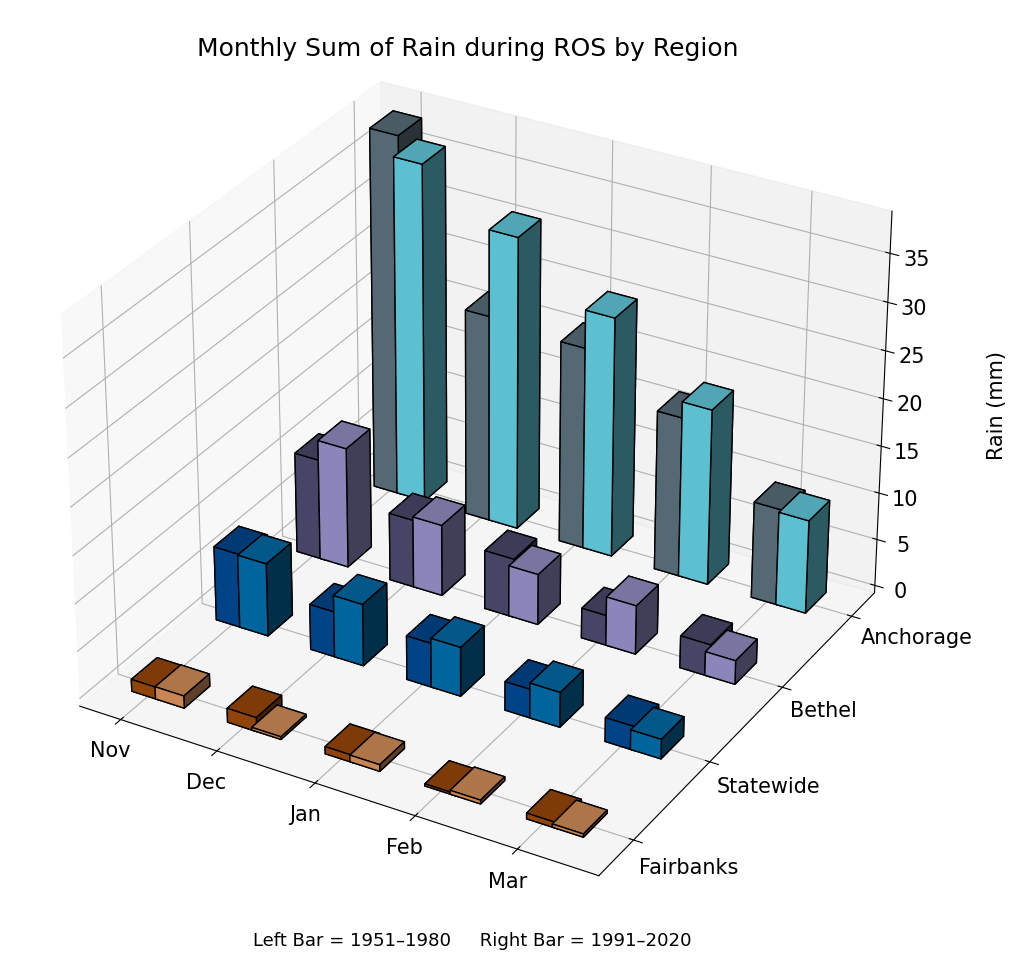

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # necessary for 3D plotting
from matplotlib.patches import Patch

borough_colors = {
    'Anchorageold': "#5f7783",   # light blue
    "Anchoragenew": "#68d9eb",   # teal green
    "Fairbanksnew": "#e3985e",   # orange
    "Fairbanksold": "#A44D0A",   # orange
    "Bethelnew": "#9c98d2",      # purple
    "Bethelold": "#504e73",      # purple
    "Statewidenew": "#0072B2" ,   # blue
    "Statewideold": "#004c99"     # dark blue
}

month_labels = ['Nov', 'Dec', 'Jan', 'Feb', 'Mar']
x = np.arange(len(month_labels))
width = 0.3
depth = 0.3 

fig = plt.figure(figsize=(25, 12)) 
ax = fig.add_subplot(111, projection='3d')
offsets = {"1951-1980": -0.1,
        "1991-2020": 0.15}

y_positions = {
    "Fairbanks": 0,
    "Anchorage": 3,
    'Statewide': 1,
    "Bethel": 2
}
# ---- Anchorage ----
ax.bar3d(x + offsets["1951-1980"], y_positions["Anchorage"]*np.ones_like(x), np.zeros_like(x), 
         width, depth, anc_sum_1950_4km, 
         color=borough_colors["Anchorageold"],  edgecolor='black', label='Anchorage 1951-1980')

ax.bar3d(x + offsets["1991-2020"], y_positions["Anchorage"]*np.ones_like(x), np.zeros_like(x), 
         width, depth, anc_sum_1991_4km, 
         color=borough_colors["Anchoragenew"], edgecolor='black', label='Anchorage 1991-2020')
#---- Statewide ----

ax.bar3d(x + offsets["1951-1980"], y_positions["Statewide"]*np.ones_like(x), np.zeros_like(x), 
         width, depth, statewidesum_1950_4km, 
         color=borough_colors["Statewideold"],  edgecolor='black', label='Statewide 1951-1980')

ax.bar3d(x + offsets["1991-2020"], y_positions["Statewide"]*np.ones_like(x), np.zeros_like(x), 
         width, depth, statewidesum_1991_4km, 
         color=borough_colors["Statewidenew"], edgecolor='black', label='Statewide 1991-2020')


# ---- Fairbanks ----
ax.bar3d(x + offsets["1951-1980"], y_positions["Fairbanks"]*np.ones_like(x), np.zeros_like(x), 
         width, depth, fai_sum_1950_4km, 
         color=borough_colors["Fairbanksold"],  edgecolor='black', label='Fairbanks 1951-1980')

ax.bar3d(x + offsets["1991-2020"], y_positions["Fairbanks"]*np.ones_like(x), np.zeros_like(x), 
         width, depth, fai_sum_1991_4km, 
         color=borough_colors["Fairbanksnew"], edgecolor='black', label='Fairbanks 1991-2020')

# ---- Bethel ----
ax.bar3d(x + offsets["1951-1980"], y_positions["Bethel"]*np.ones_like(x), np.zeros_like(x), 
         width, depth, bet_sum_1950_4km, 
         color=borough_colors["Bethelold"], edgecolor='black', label='Bethel 1951-1980')

ax.bar3d(x + offsets["1991-2020"], y_positions["Bethel"]*np.ones_like(x), np.zeros_like(x), 
         width, depth, bet_sum_1991_4km, 
         color=borough_colors["Bethelnew"], edgecolor='black', label='Bethel 1991-2020')


# Set axis labels
ax.set_xticks(x)
ax.set_xticklabels(month_labels, fontsize=15)

yticks = [0.2, 1.2, 2.2, 3.2]
labels = ['Fairbanks','Statewide','Bethel','Anchorage']
ax.set_yticklabels([])
ax.set_yticks(yticks)

for y, label in zip(yticks, labels):
    ax.text(x[-1]+1.2 , y-.5, 2, label, fontsize=15, ha='left', va='center')

ax.tick_params(axis='z', labelsize=15)
fig.text(0.71, 0.55, 'Rain (mm)', rotation=90, fontsize=15, va='center', ha='center')


#ax.set_zlabel('Rain (mm)', fontsize=12, rotation=90)
ax.set_title('Monthly Sum of Rain during ROS by Region \n', y=0.99,fontsize=18)

fig.text(.5, .1, "Left Bar = 1951–1980     Right Bar = 1991–2020", ha='center', fontsize=13)
plt.subplots_adjust(left=0.1, right=0.9)
plt.show()

In [18]:
'''
Mun_of_Anc_boundary = borough_boundaries[borough_boundaries['CommunityN'] == 'Municipality of Anchorage']
Bethel_boundary = borough_boundaries[borough_boundaries['CommunityN'] == 'Bethel Census Area']
Mat_Su_boundary=borough_boundaries[borough_boundaries['CommunityN'] == 'Matanuska-Susitna Borough']
Denali_boundary=borough_boundaries[borough_boundaries['CommunityN'] == 'Denali Borough']
'''

"\nMun_of_Anc_boundary = borough_boundaries[borough_boundaries['CommunityN'] == 'Municipality of Anchorage']\nBethel_boundary = borough_boundaries[borough_boundaries['CommunityN'] == 'Bethel Census Area']\nMat_Su_boundary=borough_boundaries[borough_boundaries['CommunityN'] == 'Matanuska-Susitna Borough']\nDenali_boundary=borough_boundaries[borough_boundaries['CommunityN'] == 'Denali Borough']\n"

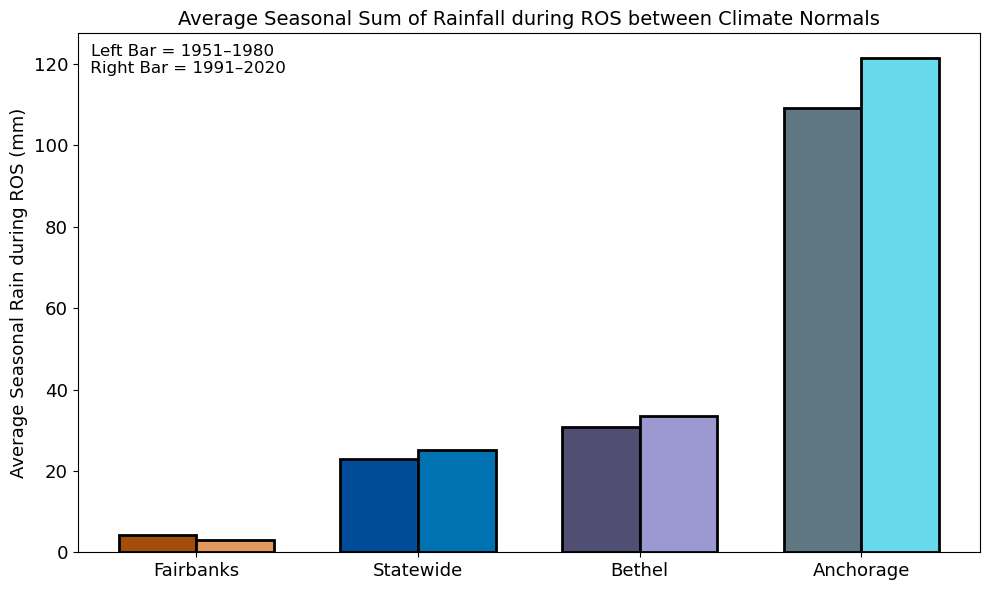

In [19]:

borough_colors = {
    'Anchorageold': "#5f7783",   # light blue
    "Anchoragenew": "#68d9eb",   # teal green
    "Fairbanksnew": "#e3985e",   # orange
    "Fairbanksold": "#A44D0A",   # orange
    "Bethelnew": "#9c98d2",      # purple
    "Bethelold": "#504e73",      # purple
    "Statewidenew": "#0072B2" ,   # blue
    "Statewideold": "#004c99"     # dark blue
}

labels = ['Fairbanks','Statewide','Bethel','Anchorage']
x = np.arange(len(labels))
width = 0.35  # width of each bar

# Values per period
old_ros = [np.sum(fai_sum_1950_4km), np.sum(statewidesum_1950_4km), np.sum(bet_sum_1950_4km), np.sum(anc_sum_1950_4km)]
new_ros = [np.sum(fai_sum_1991_4km), np.sum(statewidesum_1991_4km), np.sum(bet_sum_1991_4km),  np.sum(anc_sum_1991_4km)]



fig, ax = plt.subplots(figsize=(10,6))

# Plot bars
ax.bar(x - width/2, old_ros, width, color=[borough_colors['Fairbanksold'], borough_colors['Statewideold'], borough_colors['Bethelold'], borough_colors['Anchorageold']], edgecolor='black',  linewidth=2, label='1951-1980')
ax.bar(x + width/2, new_ros, width, color=[borough_colors['Fairbanksnew'], borough_colors['Statewidenew'], borough_colors['Bethelnew'], borough_colors['Anchoragenew']], edgecolor='black',   linewidth=2,label='1991-2020')

# Labels
ax.set_xticks(x)
ax.set_xticklabels(labels,fontsize=13)
ax.set_ylabel('Average Seasonal Rain during ROS (mm)',fontsize=13)
ax.set_title('Average Seasonal Sum of Rainfall during ROS between Climate Normals', fontsize=14)
ax.tick_params(axis='y', labelsize=13)
fig.text(0.19, 0.87, "Left Bar = 1951–1980 \n Right Bar = 1991–2020", ha='center', fontsize=12)

plt.tight_layout()
plt.show()

Exploring by elevation
-

In [240]:
era5_4km=era5_4km.fillna(0)
regridded_era5=regridded_era5.fillna(0)

In [241]:
nov_ros_tally_avg_4km=np.mean(era5_4km['ros_tally'].sel(month=11),axis=0)
dec_ros_tally_avg_4km=np.mean(era5_4km['ros_tally'].sel(month=12),axis=0)
jan_ros_tally_avg_4km=np.mean(era5_4km['ros_tally'].sel(month=1),axis=0)
feb_ros_tally_avg_4km=np.mean(era5_4km['ros_tally'].sel(month=2),axis=0)
mar_ros_tally_avg_4km=np.mean(era5_4km['ros_tally'].sel(month=3),axis=0)

nov_ros_rain_sum_avg_4km=np.mean(era5_4km['rain_ros_sum'].sel(month=11),axis=0)
dec_ros_rain_sum_avg_4km=np.mean(era5_4km['rain_ros_sum'].sel(month=12),axis=0)
jan_ros_rain_sum_avg_4km=np.mean(era5_4km['rain_ros_sum'].sel(month=1),axis=0)
feb_ros_rain_sum_avg_4km=np.mean(era5_4km['rain_ros_sum'].sel(month=2),axis=0)
mar_ros_rain_sum_avg_4km=np.mean(era5_4km['rain_ros_sum'].sel(month=3),axis=0)

In [242]:
nov_ros_tally_avg_regridded_era5=np.mean(regridded_era5['ros_tally'].sel(month=11),axis=0)
dec_ros_tally_avg_regridded_era5=np.mean(regridded_era5['ros_tally'].sel(month=12),axis=0)
jan_ros_tally_avg_regridded_era5=np.mean(regridded_era5['ros_tally'].sel(month=1),axis=0)
feb_ros_tally_avg_regridded_era5=np.mean(regridded_era5['ros_tally'].sel(month=2),axis=0)
mar_ros_tally_avg_regridded_era5=np.mean(regridded_era5['ros_tally'].sel(month=3),axis=0)

In [243]:
elevation = geo['HGT_M'].isel(Time=0)

elevation_31=xr.open_dataset('/center1/DYNDOWN/phutton5/ROS/Raw_ERA5/era531km_regridded_elevation.nc')
elevation_31=elevation_31['z'].isel(time=0)

Re = 6367.47 * 1000
g = 9.8067         

def z_to_altitude(z):
    return (z * Re) / (g * Re - z)

elevation_31 = z_to_altitude(elevation_31)
elevation_31 = elevation_31.astype('float64')

In [244]:
months = [11, 12, 1, 2, 3]

ros_tally_avg = era5_4km['ros_tally'].sel(month=months)
ros_rain_sum_avg = era5_4km['rain_ros_sum'].sel(month=months)

elevation = geo['HGT_M'].isel(Time=0)

In [245]:
elevation_ros = xr.Dataset({
    'ros_tally_avg_4km': era5_4km['ros_tally'].sel(month=months),
    'ros_rain_sum_avg_4km': era5_4km['rain_ros_sum'].sel(month=months)
})

elevation_ros_31= xr.Dataset({
    'ros_tally_avg_regridded_31km': regridded_era5['ros_tally'].sel(month=months),
    'ros_rain_sum_avg_regridded_31km' :regridded_era5['rain_ros_sum'].sel(month=months)
})

elevation_ros = elevation_ros.assign_coords(elevation=elevation)
elevation_ros_31 = elevation_ros_31.assign_coords(elevation=elevation_31)

bins = [0, 500, 1000, 1500, 2000,5000] 

In [246]:
ros_by_elev = elevation_ros['ros_tally_avg_4km'].groupby_bins(
    elevation_ros['elevation'], bins).mean()
rain_by_elev = elevation_ros['ros_rain_sum_avg_4km'].groupby_bins(
    elevation_ros['elevation'], bins).mean()


ros_by_elev_31km = elevation_ros_31['ros_tally_avg_regridded_31km'].groupby_bins(
    elevation_ros_31['elevation'], bins).mean()
rain_by_elev_31km = elevation_ros_31['ros_rain_sum_avg_regridded_31km'].groupby_bins(
    elevation_ros_31['elevation'], bins).mean()

In [247]:
seasonal_values=ros_by_elev.sum(axis=1)
seasonal_values
seasonal_values_31=ros_by_elev_31km.sum(axis=1)

/center1/DYNDOWN/phutton5/VSCODE_dump/ipykernel_3188580/3191291949.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('gist_earth', n_elev)


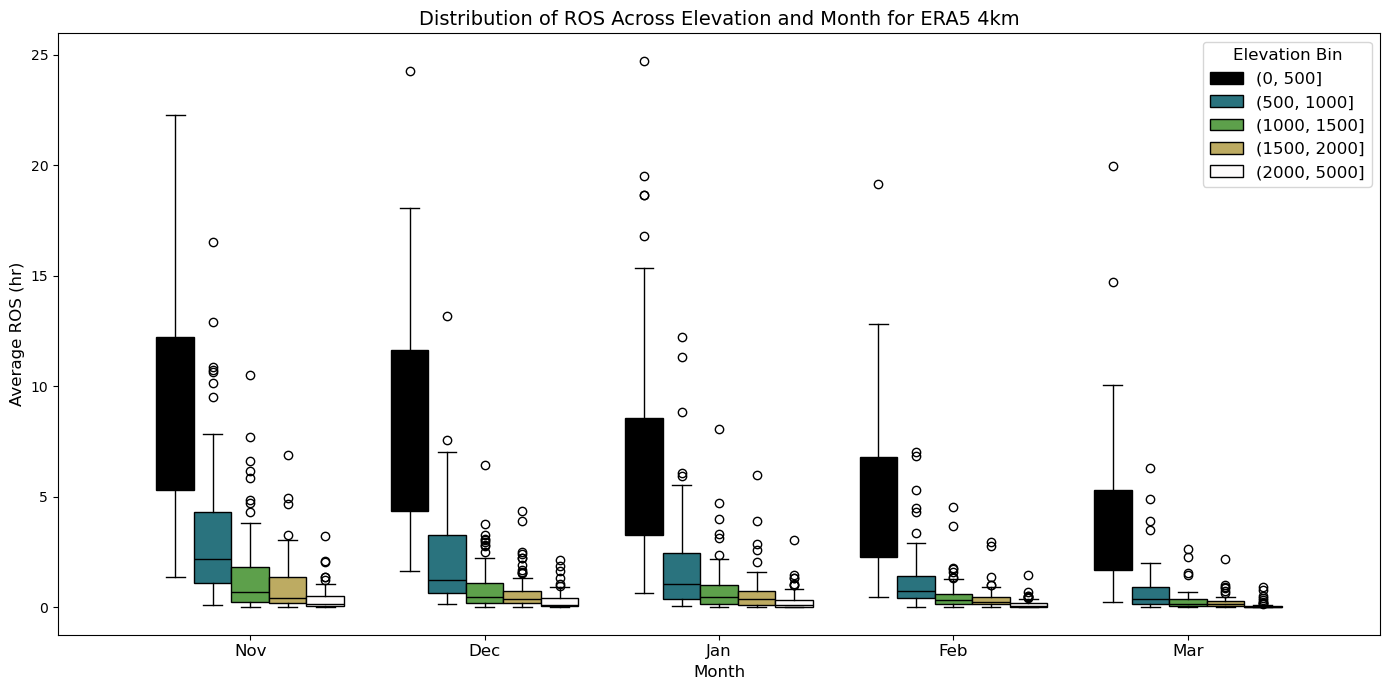

In [248]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm
from matplotlib.patches import Patch

month_labels = ['Nov', 'Dec', 'Jan', 'Feb', 'Mar']
era5_months = [0,1,2,3,4] 
n_months = len(month_labels)


elev_labels = ros_by_elev.elevation_bins.values
n_elev = len(elev_labels)

cmap = cm.get_cmap('gist_earth', n_elev)
colors = [cmap(i) for i in range(n_elev)]


total_width = 0.8
box_width = total_width / n_elev
x = np.arange(n_months)

fig, ax = plt.subplots(figsize=(14,7))

for ei, elev in enumerate(elev_labels):
    # Collect data for each month (all seasons)
    data = [ros_by_elev.sel(elevation_bins=elev).isel(month=mi).values.flatten()
            for mi in era5_months]
    
    positions = x - total_width/2 + ei*box_width + box_width/2
    
    # Plot boxes
    bp = ax.boxplot(data, positions=positions, widths=box_width, patch_artist=True)
    
    # Color the boxes
    for patch in bp['boxes']:
        patch.set_facecolor(colors[ei])
    for element in ['whiskers','caps','medians','fliers']:
        plt.setp(bp[element], color='black')


ax.set_xticks(x)
ax.set_xticklabels(month_labels, fontsize=12)
ax.set_ylabel('Average ROS (hr)', fontsize=12)
ax.set_xlabel('Month', fontsize=12)
ax.set_title('Distribution of ROS Across Elevation and Month for ERA5 4km', fontsize=14)

# Legend for elevation bins
legend_elements = [Patch(facecolor=colors[i], edgecolor='black', label=str(elev_labels[i]))
                   for i in range(n_elev)]
ax.legend(handles=legend_elements, title='Elevation Bin', fontsize=12, title_fontsize=12)

plt.tight_layout()
plt.show()

/center1/DYNDOWN/phutton5/VSCODE_dump/ipykernel_3188580/2102356557.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('gist_earth', n_elev)


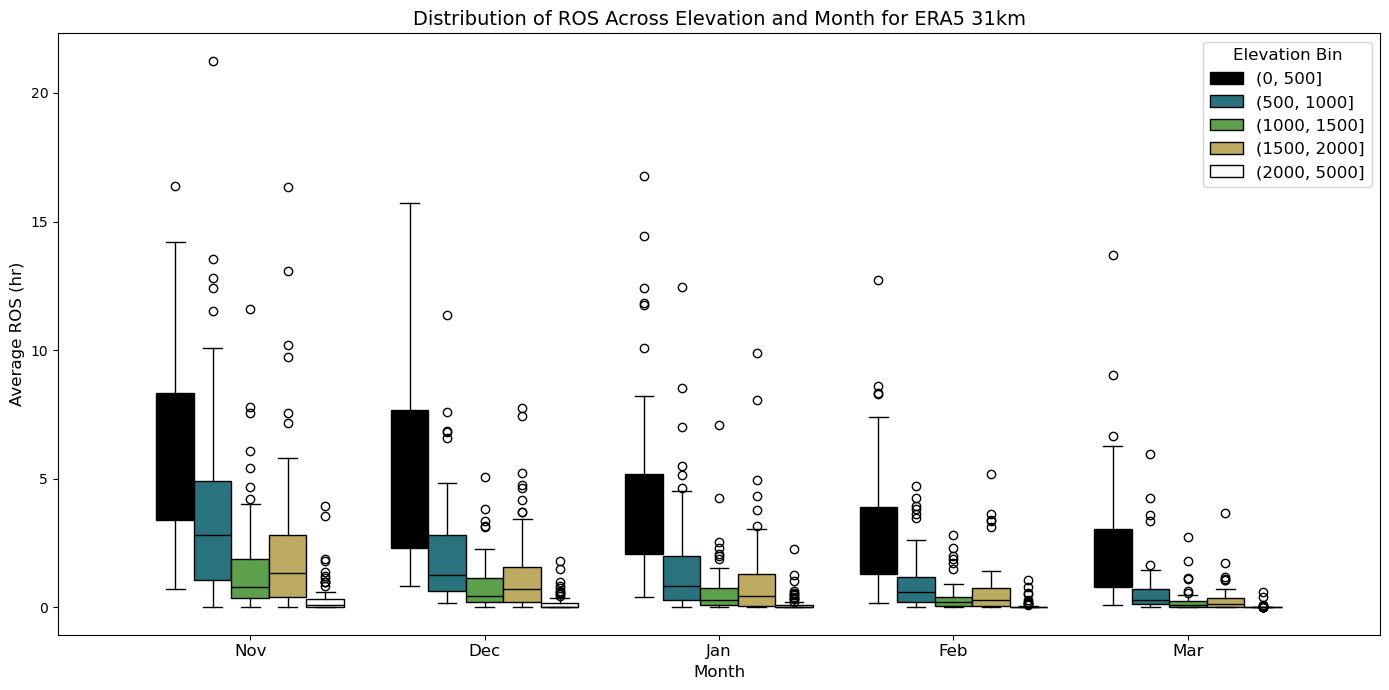

In [249]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm
from matplotlib.patches import Patch

month_labels = ['Nov', 'Dec', 'Jan', 'Feb', 'Mar']
era5_months = [0,1,2,3,4] 
n_months = len(month_labels)


elev_labels = ros_by_elev.elevation_bins.values
n_elev = len(elev_labels)

cmap = cm.get_cmap('gist_earth', n_elev)
colors = [cmap(i) for i in range(n_elev)]


total_width = 0.8
box_width = total_width / n_elev
x = np.arange(n_months)

fig, ax = plt.subplots(figsize=(14,7))

for ei, elev in enumerate(elev_labels):
    # Collect data for each month (all seasons)
    data = [ros_by_elev_31km.sel(elevation_bins=elev).isel(month=mi).values.flatten()
            for mi in era5_months]
    
    positions = x - total_width/2 + ei*box_width + box_width/2
    
    # Plot boxes
    bp = ax.boxplot(data, positions=positions, widths=box_width, patch_artist=True)
    
    # Color the boxes
    for patch in bp['boxes']:
        patch.set_facecolor(colors[ei])
    for element in ['whiskers','caps','medians','fliers']:
        plt.setp(bp[element], color='black')


ax.set_xticks(x)
ax.set_xticklabels(month_labels, fontsize=12)
ax.set_ylabel('Average ROS (hr)', fontsize=12)
ax.set_xlabel('Month', fontsize=12)
ax.set_title('Distribution of ROS Across Elevation and Month for ERA5 31km', fontsize=14)

# Legend for elevation bins
legend_elements = [Patch(facecolor=colors[i], edgecolor='black', label=str(elev_labels[i]))
                   for i in range(n_elev)]
ax.legend(handles=legend_elements, title='Elevation Bin', fontsize=12, title_fontsize=12)

plt.tight_layout()
plt.show()

In [250]:
ros_count_4km = elevation_ros['ros_tally_avg_4km'].groupby_bins(
    elevation_ros['elevation'], bins).count()

ros_count_31km = elevation_ros_31['ros_tally_avg_regridded_31km'].groupby_bins(
    elevation_ros['elevation'], bins
).count()

/center1/DYNDOWN/phutton5/VSCODE_dump/ipykernel_3188580/3098863914.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('gist_earth', n_elev)


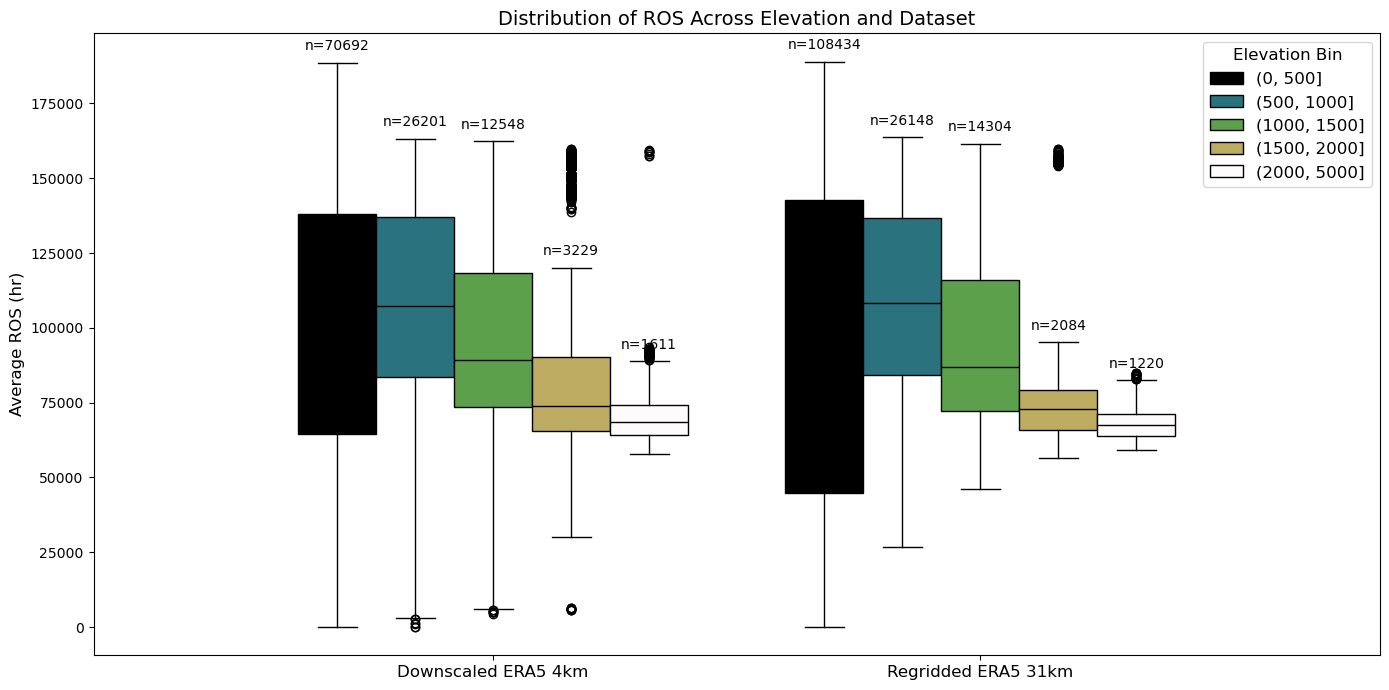

In [251]:
ros_by_elev_4km = elevation_ros['ros_tally_avg_4km'].groupby_bins(
    elevation_ros['elevation'], bins
)

ros_by_elev_31km = elevation_ros_31['ros_tally_avg_regridded_31km'].groupby_bins(
    elevation_ros_31['elevation'], bins
)

# Get elevation bin labels
elev_labels = list(ros_by_elev_4km.groups.keys())
n_elev = len(elev_labels)

ros_box_4km = [np.array(ros_by_elev_4km.groups[e]).flatten() for e in elev_labels]
ros_box_31km = [np.array(ros_by_elev_31km.groups[e]).flatten() for e in elev_labels]

ros_count_4km = [np.array(ros_by_elev_4km.groups[e]).size for e in elev_labels]
ros_count_31km = [np.array(ros_by_elev_31km.groups[e]).size for e in elev_labels]


data_labels = ['Downscaled ERA5 4km', 'Regridded ERA5 31km']
n_datasets = len(data_labels)

cmap = cm.get_cmap('gist_earth', n_elev)
colors = [cmap(i) for i in range(n_elev)]

total_width = 0.8  # width of each dataset group
box_width = total_width / n_elev
x = np.arange(n_datasets)  # positions for dataset groups

fig, ax = plt.subplots(figsize=(14,7))

for ei, elev in enumerate(elev_labels):
    # Data and counts for current elevation bin
    data = [ros_box_4km[ei], ros_box_31km[ei]]
    counts = [ros_count_4km[ei], ros_count_31km[ei]]
    
    # Positions: offset each elevation bin inside each dataset group
    positions = x - total_width/2 + ei*box_width + box_width/2
    
    # Boxplot
    bp = ax.boxplot(data, positions=positions, widths=box_width, patch_artist=True)
    
    # Set box colors
    for patch in bp['boxes']:
        patch.set_facecolor(colors[ei])
    for element in ['whiskers','caps','medians','fliers']:
        plt.setp(bp[element], color='black')
    
    # Annotate n= above each box
    for i, pos in enumerate(positions):
        top_whisker = bp['whiskers'][2*i+1].get_ydata()[1]
        ax.text(pos, top_whisker + 0.02*np.ptp(ax.get_ylim()), f'n={counts[i]}',
                ha='center', fontsize=10, color='black')


ax.set_xticks(x)
ax.set_xticklabels(data_labels, fontsize=12)
ax.set_ylabel('Average ROS (hr)', fontsize=12)
ax.set_title('Distribution of ROS Across Elevation and Dataset', fontsize=14)

# Legend for elevation bins
legend_elements = [Patch(facecolor=colors[i], edgecolor='black', label=str(elev_labels[i]))
                   for i in range(n_elev)]
ax.legend(handles=legend_elements, title='Elevation Bin', fontsize=12, title_fontsize=12)

plt.tight_layout()
plt.show()

/center1/DYNDOWN/phutton5/VSCODE_dump/ipykernel_3188580/4349602.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('gist_earth', n_elev)


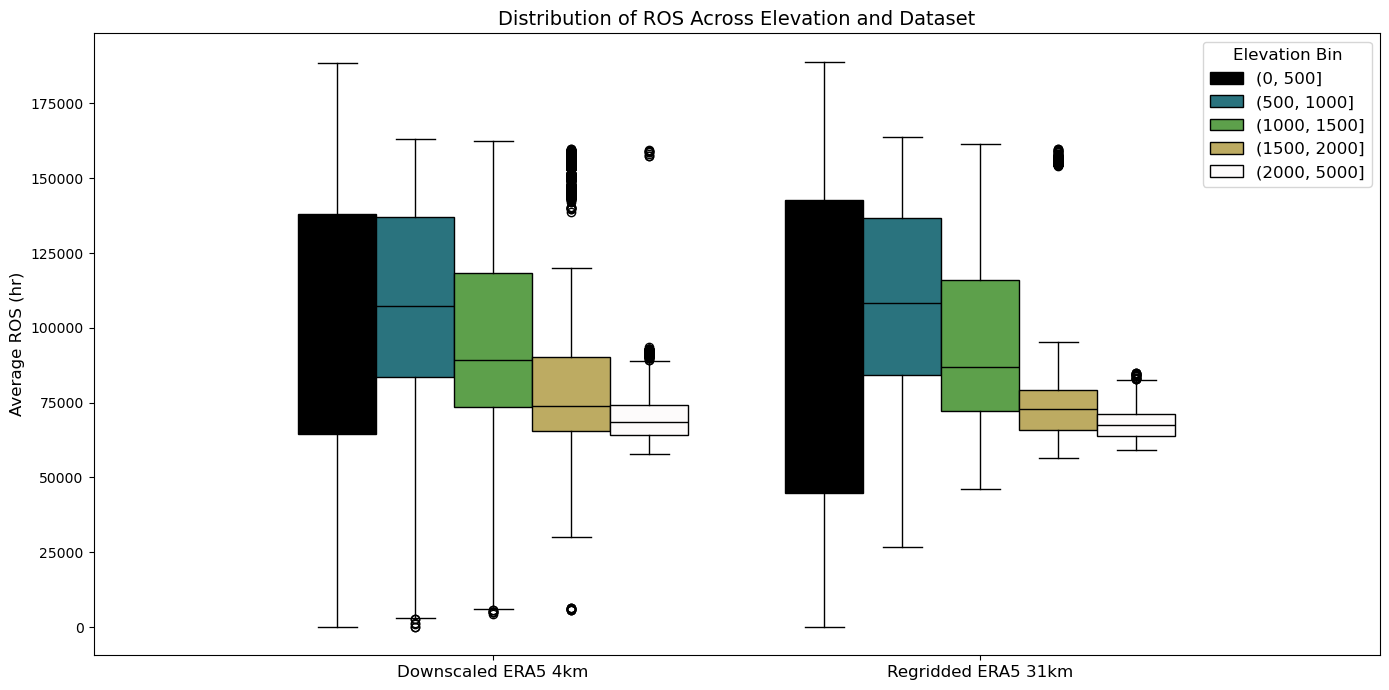

In [334]:
ros_by_elev_4km = elevation_ros['ros_tally_avg_4km'].groupby_bins(
    elevation_ros['elevation'], bins
)

ros_by_elev_31km = elevation_ros_31['ros_tally_avg_regridded_31km'].groupby_bins(
    elevation_ros_31['elevation'], bins
)

elev_labels = list(ros_by_elev_4km.groups.keys())
n_elev = len(elev_labels)

ros_box_4km = [np.array(ros_by_elev_4km.groups[e]).flatten() for e in elev_labels]
ros_box_31km = [np.array(ros_by_elev_31km.groups[e]).flatten() for e in elev_labels]

ros_count_4km = [np.array(ros_by_elev_4km.groups[e]).size for e in elev_labels]
ros_count_31km = [np.array(ros_by_elev_31km.groups[e]).size for e in elev_labels]

data_labels = ['Downscaled ERA5 4km', 'Regridded ERA5 31km']
n_datasets = len(data_labels)

cmap = cm.get_cmap('gist_earth', n_elev)
colors = [cmap(i) for i in range(n_elev)]

total_width = 0.8 
box_width = total_width / n_elev
x = np.arange(n_datasets)  

fig, ax = plt.subplots(figsize=(14,7))

for ei, elev in enumerate(elev_labels):
    data = [ros_box_4km[ei], ros_box_31km[ei]]
    counts = [ros_count_4km[ei], ros_count_31km[ei]]
    
    positions = x - total_width/2 + ei*box_width + box_width/2
    
    bp = ax.boxplot(data, positions=positions, widths=box_width, patch_artist=True)
    
    for patch in bp['boxes']:
        patch.set_facecolor(colors[ei])
    for element in ['whiskers','caps','medians','fliers']:
        plt.setp(bp[element], color='black')
    
    # Annotate n= above each box
    '''for i, pos in enumerate(positions):
        top_whisker = bp['whiskers'][2*i+1].get_ydata()[1]
        ax.text(pos, top_whisker + 0.02*np.ptp(ax.get_ylim()), f'n={counts[i]}',
                ha='center', fontsize=10, color='black')'''


ax.set_xticks(x)
ax.set_xticklabels(data_labels, fontsize=12)
ax.set_ylabel('Average ROS (hr)', fontsize=12)
ax.set_title('Distribution of ROS Across Elevation and Dataset', fontsize=14)

# Legend for elevation bins
legend_elements = [Patch(facecolor=colors[i], edgecolor='black', label=str(elev_labels[i]))
                   for i in range(n_elev)]
ax.legend(handles=legend_elements, title='Elevation Bin', fontsize=12, title_fontsize=12)

plt.tight_layout()
plt.show()

In [335]:
ros_count_4km

[70692, 26201, 12548, 3229, 1611]

In [336]:
ros_count_31km

[108434, 26148, 14304, 2084, 1220]

In [338]:
total_points_4km = sum(ros_count_4km)
total_points_31km = sum(ros_count_31km)

print(f"Total ROS points in 4km dataset: {total_points_4km}")
print(f"Total ROS points in 31km dataset: {total_points_31km}")
total_points_31km-total_points_4km

Total ROS points in 4km dataset: 114281
Total ROS points in 31km dataset: 152190


37909

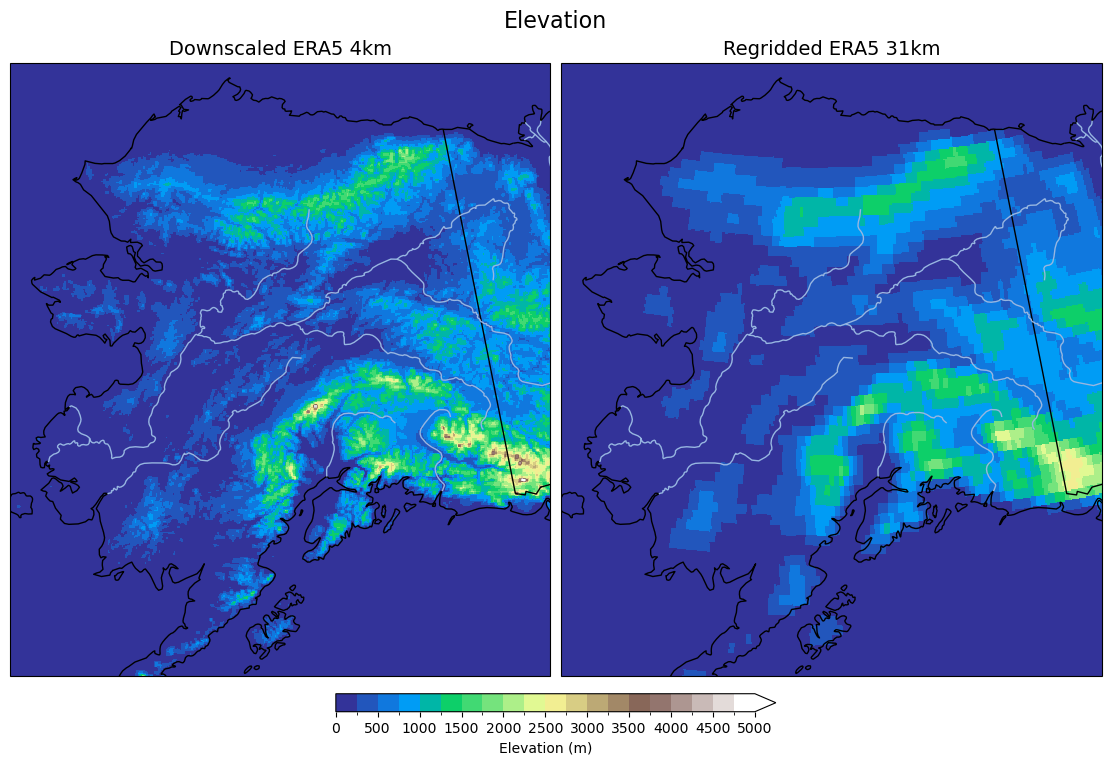

In [305]:
from matplotlib.colors import BoundaryNorm

AK_ALBERS_SUBPLOT_KW = {
    'projection': ccrs.AlbersEqualArea(
        central_longitude=-154, central_latitude=50,
        standard_parallels=(55, 65))
}

# Define discrete elevation bins
levels = np.arange(0, 5250, 250)  # 0, 500, 1000, ..., 5000
cmap = plt.get_cmap('terrain')

# Create a norm for discrete color bins
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)

# Create subplots
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(11,9), subplot_kw=AK_ALBERS_SUBPLOT_KW, constrained_layout=True)

# 4km data
pc1 = axs[0].pcolormesh(
    elevation_ros['XLONG'], elevation_ros['XLAT'], 
    elevation_ros['elevation'], 
    cmap=cmap, norm=norm,  # Apply the BoundaryNorm here
    shading='auto', transform=ccrs.PlateCarree()
)
axs[0].set_title("Downscaled ERA5 4km", fontsize=14)

# 31km data
pc2 = axs[1].pcolormesh(
    elevation_ros_31['XLONG'], elevation_ros_31['XLAT'], 
    elevation_ros_31['elevation'], 
    cmap=cmap, norm=norm,  # Apply the BoundaryNorm here
    shading='auto', transform=ccrs.PlateCarree()
)
axs[1].set_title("Regridded ERA5 31km", fontsize=14)

# Add map features
for ax in axs:
    ax.add_feature(cfeature.BORDERS, zorder=8)
    ax.add_feature(cfeature.COASTLINE, zorder=8)
    ax.add_feature(cfeature.RIVERS, zorder=8)
    ax.set_extent([-165.3, -141, 55.8, 71.38], crs=ccrs.PlateCarree())
    ax.set_aspect('equal')

# Add colorbar
cbar_ax = fig.add_axes([0.3, 0.12, 0.4, 0.02])
cbar = fig.colorbar(pc1, cax=cbar_ax, orientation='horizontal', ticks=levels[::2], extend='max', label='Elevation (m)')

fig.suptitle("Elevation", fontsize=16, y=0.90)
fig.patch.set_alpha(0.0)
plt.show()

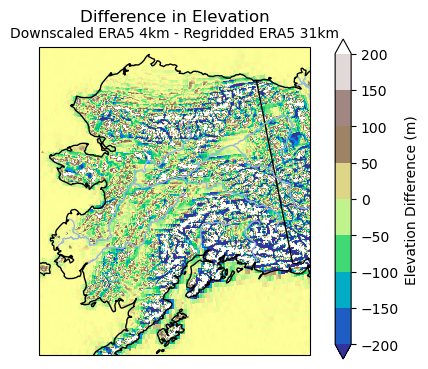

In [288]:
AK_ALBERS_SUBPLOT_KW = {'projection': ccrs.AlbersEqualArea(central_longitude=-154, central_latitude=50,standard_parallels=(55, 65))}
fig, ax = plt.subplots(subplot_kw=AK_ALBERS_SUBPLOT_KW, figsize=(10, 4))
fig.patch.set_alpha(0)
ax.set_facecolor('none')
levels=np.arange(-200,250,50)
cf = ax.pcolormesh(elevation_ros['XLONG'], elevation_ros['XLAT'], (elevation_ros['elevation']-elevation_ros_31['elevation']),vmin=-200, vmax=200,cmap='terrain',shading='auto',transform=ccrs.PlateCarree())

cbar = fig.colorbar(cf, ax=ax, boundaries=levels,label='Elevation Difference (m)',extend='both')
cbar.ax.set_position([0.77, 0.1, 0.02, 0.8])
ax.add_feature(cfeature.BORDERS, zorder=9)
ax.add_feature(cfeature.COASTLINE, zorder=9)
ax.add_feature(cfeature.RIVERS, zorder=9)

ax.set_title("Difference in Elevation\n",fontsize=12)
ax.text(0.5, 1.03, "Downscaled ERA5 4km - Regridded ERA5 31km", transform=ax.transAxes, fontsize=10, ha='center')
ax.set_extent([-165.3, -141, 55.8, 71.38], crs=ccrs.PlateCarree())
ax.set_aspect('equal') 
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.show()

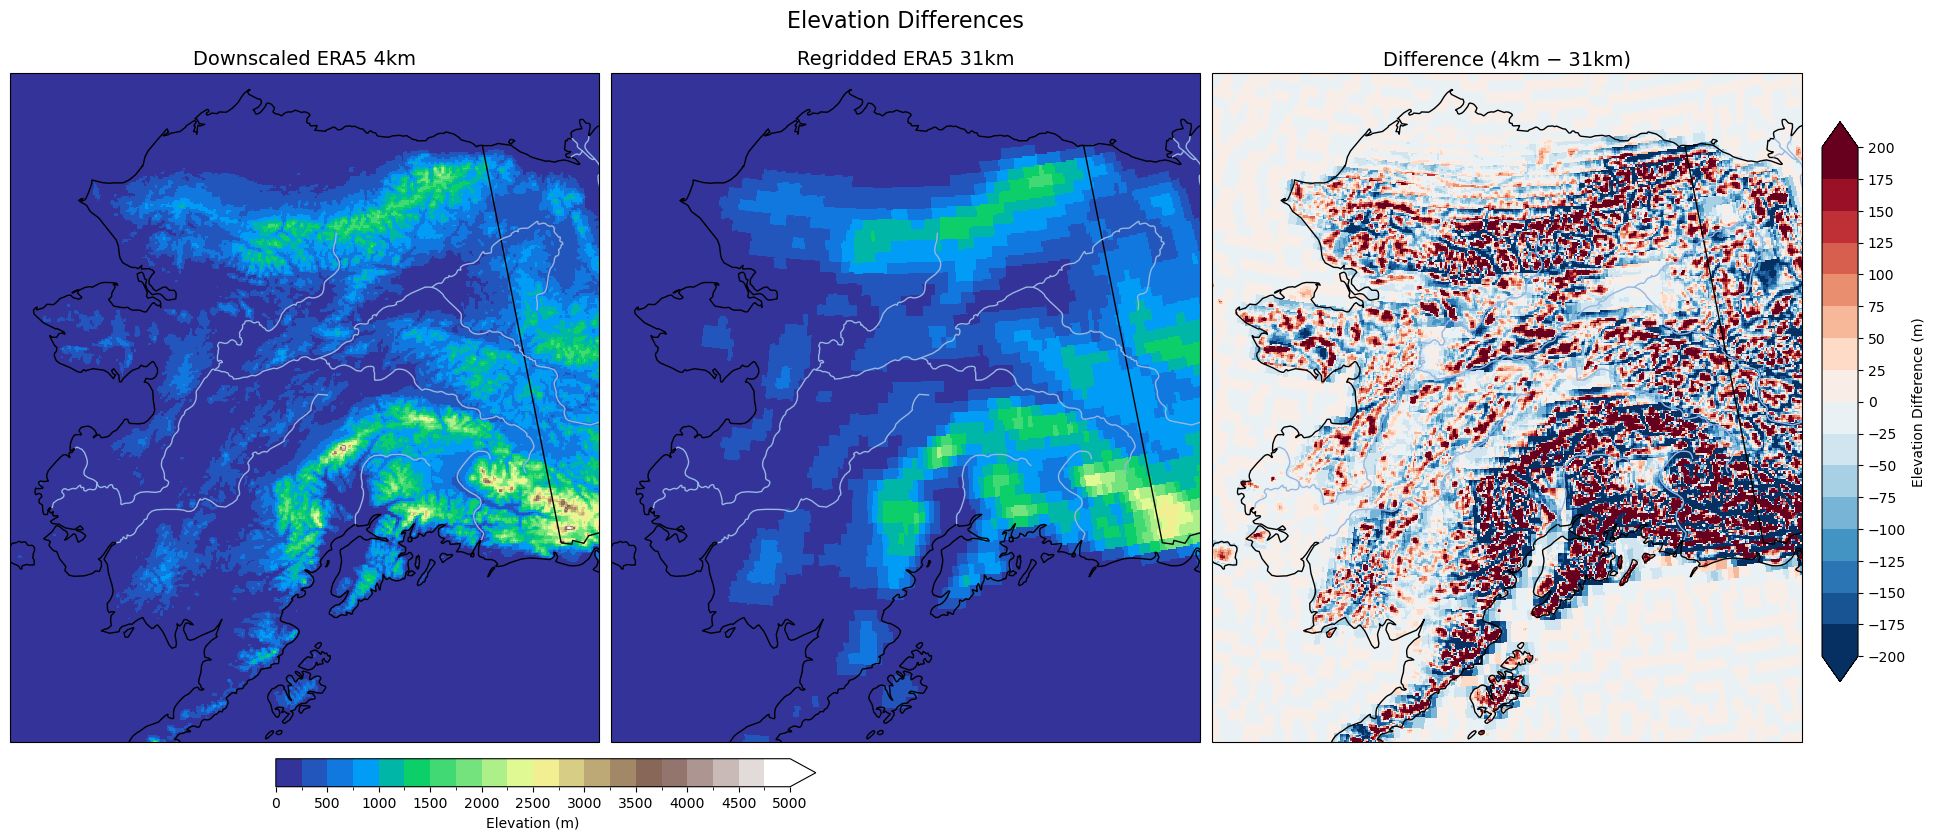

In [ ]:
from matplotlib.colors import BoundaryNorm
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# Define Albers projection
AK_ALBERS_SUBPLOT_KW = {
    'projection': ccrs.AlbersEqualArea(
        central_longitude=-154, central_latitude=50,
        standard_parallels=(55, 65))
}


elev_levels = np.arange(0, 5250, 250)
elev_cmap = plt.get_cmap('terrain')
elev_norm = BoundaryNorm(elev_levels, ncolors=elev_cmap.N, clip=True)


diff_levels = np.arange(-200, 225, 25)
diff_cmap = plt.get_cmap('RdBu_r')
diff_norm = BoundaryNorm(diff_levels, ncolors=diff_cmap.N, clip=True)
diff_data = elevation_ros['elevation'] - elevation_ros_31['elevation']


fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(18,7),
                        subplot_kw=AK_ALBERS_SUBPLOT_KW,
                        constrained_layout=True)

# Panel 1: 4km elevation
pc1 = axs[0].pcolormesh(
    elevation_ros['XLONG'], elevation_ros['XLAT'],
    elevation_ros['elevation'],
    cmap=elev_cmap, norm=elev_norm,
    shading='auto', transform=ccrs.PlateCarree()
)
axs[0].set_title("Downscaled ERA5 4km", fontsize=14)

# Panel 2: 31km elevation
pc2 = axs[1].pcolormesh(
    elevation_ros_31['XLONG'], elevation_ros_31['XLAT'],
    elevation_ros_31['elevation'],
    cmap=elev_cmap, norm=elev_norm,
    shading='auto', transform=ccrs.PlateCarree()
)
axs[1].set_title("Regridded ERA5 31km", fontsize=14)

# Panel 3: Difference
pc3 = axs[2].pcolormesh(
    elevation_ros['XLONG'], elevation_ros['XLAT'],
    diff_data,
    cmap=diff_cmap, norm=diff_norm,
    shading='auto', transform=ccrs.PlateCarree()
)
axs[2].set_title("Difference (4km − 31km)", fontsize=14)

# Add map features to all panels
for ax in axs:
    ax.add_feature(cfeature.BORDERS, zorder=8)
    ax.add_feature(cfeature.COASTLINE, zorder=8)
    ax.add_feature(cfeature.RIVERS, zorder=8)
    ax.set_extent([-165.3, -141, 55.8, 71.38], crs=ccrs.PlateCarree())
    ax.set_aspect('equal')


cbar_ax1 = fig.add_axes([0.15, -0.05, 0.3, 0.04])

cbar1 = fig.colorbar(pc1, cax=cbar_ax1, orientation='horizontal',
                     ticks=elev_levels[::2], extend='max', label='Elevation (m)')

# Vertical colorbar for difference panel
cbar_ax2 = fig.add_axes([1.009, 0.1, 0.02, 0.8])
cbar2 = fig.colorbar(pc3, cax=cbar_ax2, orientation='vertical', ticks=diff_levels, extend='both', label='Elevation Difference (m)')

fig.suptitle("Elevation Differences", fontsize=16, y=1.06)
fig.patch.set_alpha(0.0)

plt.show()